## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this second laboratory we will gain some experience working with Transformer models for a variety tasks using (mostly) the Hugging Face Ecosystem. 


---
### Exercise 1: Sentiment Analysis (warm up)

In this first exercise we will start from a pre-trained BERT transformer and build up a model able to perform text sentiment analysis. Transformers are complex beasts, so we will build up our pipeline in several explorative and incremental steps.

#### Exercise 1.1: Loading the Dataset Splits
There are a many sentiment analysis datasets, but we will use one of the smallest ones available: the [Cornell Rotten Tomatoes movie review dataset](https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes), which consists of 5,331 positive and 5,331 negative processed sentences from the Rotten Tomatoes movie reviews.

**Your first task**: Load the dataset and figure out what splits are available and how to get them. Spend some time exploring the dataset to see how it is organized. Note that we will be using the [HuggingFace Datasets](https://huggingface.co/docs/datasets/en/index) library for downloading, accessing, splitting, and batching data for training and evaluation.

In [ ]:
import sys

executable_with_quotes = f'"{sys.executable}"'

# 1. Ripristiniamo pip
!{executable_with_quotes} -m ensurepip --default-pip

# 2. Installiamo i pacchetti necessari
!{executable_with_quotes} -m pip install datasets "transformers[torch]" scikit-learn

Looking in links: c:\Users\HP\AppData\Local\Temp\tmptm8qhaby
Processing c:\users\hp\appdata\local\temp\tmptm8qhaby\pip-25.0.1-py3-none-any.whl
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/529.0 kB ? eta -:--:--
   ---------------------------------------- 529.0/529.0 kB 4.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.0 MB 5.6 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.0 MB 6.1 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.0 MB 6.7 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.0 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 7.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/668.2 kB ? eta -:--:--
   ---------------------------------------- 668.2/668.2


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import sys
!"{sys.executable}" -m pip install ipywidgets

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 914.9/914.9 kB 6.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 20.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Dataset imports.
import os
from datasets import load_dataset, get_dataset_split_names, load_from_disk

# 1. Scopriamo quali sono gli split disponibili nel dataset senza scaricarlo interamente
dataset_name = "cornell-movie-review-data/rotten_tomatoes"
splits = get_dataset_split_names(dataset_name) # interogazione sul partizionamento
print(f"Gli split disponibili nel dataset sono: {splits}")

# Definiamo il percorso della cartella locale in cui salvare il dataset
local_path = "./rotten_tomatoes_local"

# 2. Carichiamo il dataset (da locale se esiste già, altrimenti dall'Hub)
if os.path.exists(local_path): # controlla se esiste già la cartella
    print(f"\nCartella locale trovata! Caricamento del dataset da: {local_path}")
    raw_datasets = load_from_disk(local_path)
else:
    print("\nCartella locale non trovata. Download del dataset dall'Hugging Face Hub...")
    raw_datasets = load_dataset(dataset_name) # se non esiste lo scarica
    
    # Salvataggio in locale per i futuri utilizzi
    raw_datasets.save_to_disk(local_path) # salva il dataset in locale
    print(f"Dataset salvato con successo in locale nella cartella: {local_path}")

print("\nStruttura del dataset caricato:")
print(raw_datasets)

# 3. Esploriamo un esempio dello split di addestramento ('train') per capire i campi disponibili
print("\nEsempio del primo elemento dello split di 'train':")
print(raw_datasets["train"][0])

# 4. Vediamo quanti elementi ci sono per ogni split
for split in splits:
    print(f"Numero di elementi in '{split}': {len(raw_datasets[split])}")

Gli split disponibili nel dataset sono: ['train', 'validation', 'test']

Cartella locale trovata! Caricamento del dataset da: ./rotten_tomatoes_local

Struttura del dataset caricato:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})

Esempio del primo elemento dello split di 'train':
{'text': 'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .', 'label': 1}
Numero di elementi in 'train': 8530
Numero di elementi in 'validation': 1066
Numero di elementi in 'test': 1066


In [3]:
!pip install matplotlib seaborn pandas wordcloud

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.2 MB 6.3 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.2 MB 8.7 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.2 MB 9.1 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.2 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 9.6 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 10.3 MB/s eta 0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


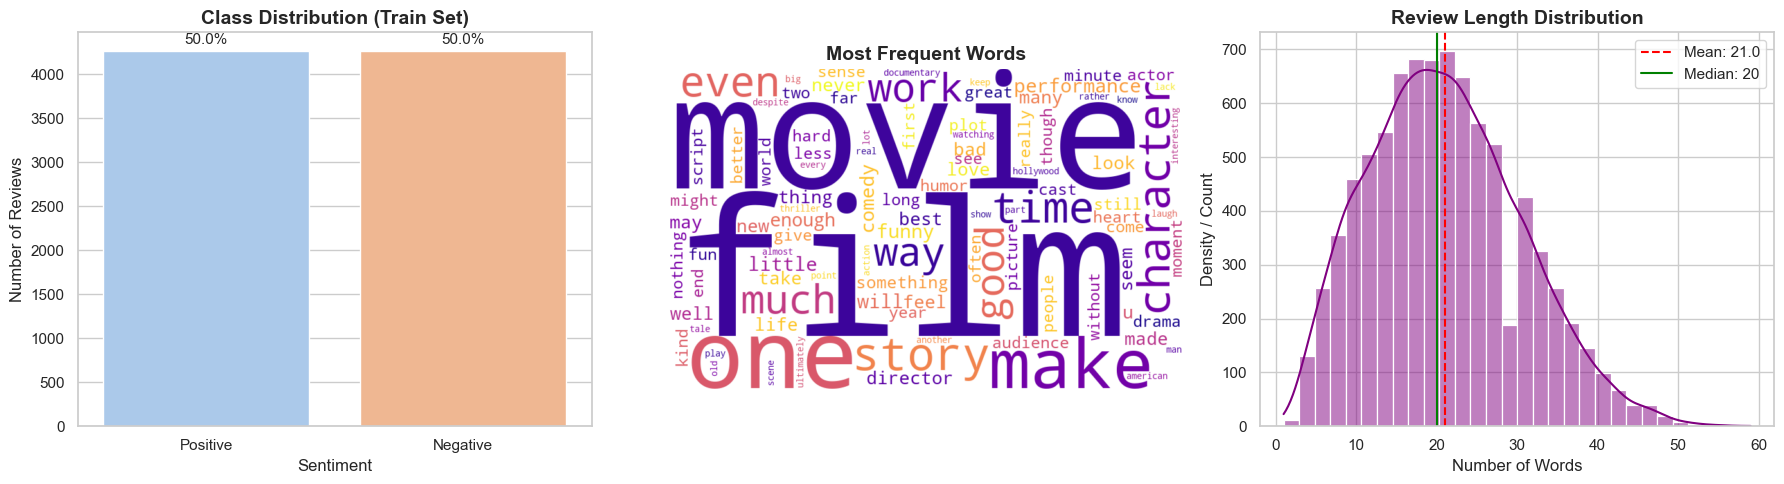

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from wordcloud import WordCloud

# 1. Configurazione dello stile dei grafici
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # tre grafici affiancati

# Prepariamo i dati usando 'raw_datasets' (il nome corretto della variabile desiderata)
df_train = pd.DataFrame(raw_datasets['train'])


# GRAFICO 1: Distribuzione delle classi (Barplot)

# Mappiamo i nodi 0 e 1 in etichette leggibili
label_map = {0: 'Negative', 1: 'Positive'}
df_train['label_name'] = df_train['label'].map(label_map)

sns.countplot(data=df_train, x='label_name', ax=axes[0], palette='pastel', hue='label_name', legend=False) # conteggio occorrenze per categoria
axes[0].set_title('Class Distribution (Train Set)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Reviews')

# Aggiunge le percentuali sopra le barre
total = len(df_train)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    axes[0].annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() + 50),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11)


# GRAFICO 2: Word Cloud delle recensioni

# Uniamo tutto il testo in un'unica stringa
all_text = " ".join(review for review in df_train['text'])

# Generiamo la Word Cloud: concatenazione di ogni recensione separate con uno spazio
wordcloud = WordCloud(width=800, height=500, 
                      background_color='white', 
                      colormap='plasma', 
                      max_words=100, 
                      random_state=42).generate(all_text)

axes[1].imshow(wordcloud, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Frequent Words', fontsize=14, fontweight='bold')


# GRAFICO 3: Istogramma della lunghezza delle recensioni

# Calcoliamo il numero di parole per ogni recensione
df_train['review_length'] = df_train['text'].apply(lambda x: len(x.split()))

sns.histplot(data=df_train, x='review_length', ax=axes[2], kde=True, color='purple', bins=30)
axes[2].set_title('Review Length Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Number of Words')
axes[2].set_ylabel('Density / Count')

# Calcolo della lunghezza media e mediana da mostrare nel grafico
mean_len = df_train['review_length'].mean()
median_len = df_train['review_length'].median()
axes[2].axvline(mean_len, color='red', linestyle='--', label=f'Mean: {mean_len:.1f}')
axes[2].axvline(median_len, color='green', linestyle='-', label=f'Median: {median_len:.0f}')
axes[2].legend()


# Mostra il plot finale

plt.tight_layout()
plt.show()

## Analisi del Cornell Rotten Tomatoes Dataset 

Per questo laboratorio di Sentiment Analysis abbiamo utilizzato il dataset **Rotten Tomatoes** (noto anche come *Cornell Movie Review Dataset*), uno dei benchmark classici e più utilizzati nel campo del Machine Learning e del Processamento del Linguaggio Naturale (NLP).

### 1. Caratteristiche del Dataset
Il dataset è strutturato per un compito di **classificazione binaria del testo**. L'obiettivo è analizzare brevi recensioni cinematografiche estratte dal celebre sito *Rotten Tomatoes* e prevedere se il giudizio espresso sia positivo o negativo.

* **Features (Campi):**
    * `text` (Stringa): Il testo della recensione cartacea o digitale (spesso limitato a una singola frase o a poche righe).
    * `label` (Intero): L'etichetta del sentiment mappata come segue:
        * **`1`** $\rightarrow$ **Sentiment Positivo** (Recensione "Fresh")
        * **`0`** $\rightarrow$ **Sentiment Negativo** (Recensione "Rotten")
* **Origine Linguistica:** Il testo è interamente in lingua inglese, non pre-elaborato (mantiene punteggiatura e minuscole), il che lo rende ideale per testare le capacità di comprensione contestuale di modelli di linguaggio pre-addestrati come **DistilBERT**.

---

### 2. Commento e Analisi dei Risultati del Dataloader

Analizzando l'output generato dal caricamento del dataset, possiamo fare alcune osservazioni:

I dati sono organizzati in un oggetto standard di Hugging Face chiamato DatasetDict, suddiviso rigorosamente nei tre split fondamentali per un corretto workflow di Deep Learning:
1. **Train**: 8530 osservazioni - 80%
2. **Validation**: 1066 osservazioni - 10 %
3. **Test**: 1066 osservazioni - 10%

Il dataset è perfettamente bilanciato. Lo split di validazione e di test contengono l'esatta stessa quantità di dati ($1066$ righe ciascuno), il che rende le metriche di accuratezza confrontabili in modo robusto.

Prendendo il primo campione del training set come esempio, notiamo le sfide intrinseche di questo dataset:

1. **Presenza di entità complesse**: Vengono citati molti nomi propri (The Rock, Conan, Schwarzenegger, Van Damme, Segal).
2. **Verifica della Label**: La frase paragona l'attore ai pilastri del cinema d'azione del passato in modo fortemente celebrativo ("destined to be...", "make a splash even greater"). La label assegnata è infatti 1 (Positivo), confermando la coerenza dell'annotazione manuale del dataset.



---
### Exercise 1.2: A Pre-trained BERT and Tokenizer

The model we will use is a *very* small BERT transformer called [DistilBERT](https://huggingface.co/distilbert/distilbert-base-uncased) this model was trained (using self-supervised learning) on the same corpus as BERT but using the full BERT base model as a *teacher*.

**Your next task**: Load the DistilBERT model and corresponding tokenizer. Use the tokenizer on a few samples from the dataset and pass the tokens through the model to see what outputs are provided. I suggest you use the [`AutoModel`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html) class (and the `from_pretrained()` method) to load the model and `AutoTokenizer` to load the tokenizer).

In [6]:
import torch
from transformers import AutoTokenizer, AutoModel

# 1. Definiamo l'identificativo del modello pre-addestrato
model_ckpt = "distilbert/distilbert-base-uncased"

# 2. Carichiamo il Tokenizer e il Modello base dall'ecosistema Hugging Face
print("Caricamento di DistilBERT e del suo Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModel.from_pretrained(model_ckpt)
print("Caricamento completato con successo!")

# 3. Estraiamo due frasi di esempio dal dataset appena salvato
sample_sentences = [raw_datasets["train"][0]["text"], raw_datasets["train"][1]["text"]]
print(f"\n--- Frasi di Esempio Selezionate ---")
print(f"Frase 1: '{sample_sentences[0]}'")
print(f"Frase 2: '{sample_sentences[1]}'")

# 4. Fase di Tokenizzazione
# padding=True aggiunge token vuoti alla frase più corta per uniformare la lunghezza del batch
# truncation=True taglia le frasi se superano la lunghezza massima consentita dal modello (512 token)
# return_tensors="pt" restituisce i dati sotto forma di Tensori PyTorch
inputs = tokenizer(sample_sentences, padding=True, truncation=True, return_tensors="pt")

print("\n--- Output del Tokenizer ---")
print("Chiavi del dizionario generato:", list(inputs.keys()))
print("Formato del tensore 'input_ids' [Batch_Size, Sequence_Length]:", inputs["input_ids"].shape)
print("Esempio di input_ids mappati in numeri:\n", inputs["input_ids"][0])

# 5. Passiamo i vettori numerici dentro DistilBERT
# Usiamo torch.no_grad() perché in questa fase esplorativa non dobbiamo fare addestramento (no calcolo dei gradienti)
with torch.no_grad():
    outputs = model(**inputs)

print("\n--- Output di DistilBERT ---")
print("Chiavi restituite dal modello:", list(outputs.keys()))
# last_hidden_state contiene le rappresentazioni vettoriali generate dall'ultimo strato del Transformer
print("Formato di 'last_hidden_state' [Batch_Size, Sequence_Length, Hidden_Size]:", outputs.last_hidden_state.shape)

Caricamento di DistilBERT e del suo Tokenizer...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Caricamento completato con successo!

--- Frasi di Esempio Selezionate ---
Frase 1: 'the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .'
Frase 2: 'the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co-writer/director peter jackson's expanded vision of j . r . r . tolkien's middle-earth .'

--- Output del Tokenizer ---
Chiavi del dizionario generato: ['input_ids', 'token_type_ids', 'attention_mask']
Formato del tensore 'input_ids' [Batch_Size, Sequence_Length]: torch.Size([2, 52])
Esempio di input_ids mappati in numeri:
 tensor([  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
         1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
         1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
        29058,  8625, 13327,

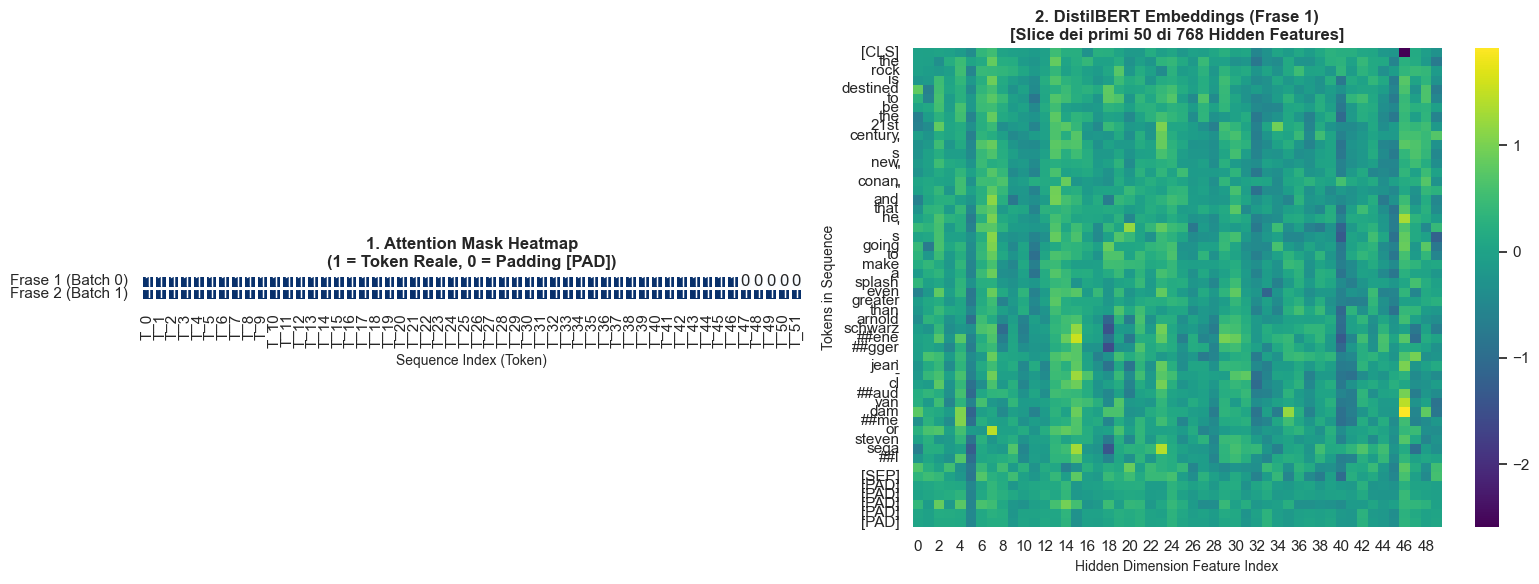


 RAPPRESENTAZIONE GEOMETRICA DEL TENSORE DI OUTPUT (Last Hidden State)
Il tuo output ha una struttura 3D con shape: [2, 52, 768]

 Puoi immaginare questo blocco di dati come un parallelepipedo tridimensionale:
  +-----------------------------------+
  |                                   |  |
  |      HIDDEN FEATURES (768)        |  |  BATCH SIZE (2 frasi)
  |  (Rappresentazione semantica)     |  |  (Profondità del tensore)
  |                                   |  +
  +-----------------------------------+
    \                                   \
     \      SEQUENCE LENGTH (52 tokens)     \
      +-----------------------------------+

Dettaglio degli assi:
 -> Asse 0 (Batch): Ogni fetta corrisponde a una frase del batch (nel tuo caso 2 frasi).
 -> Asse 1 (Sequence): Ogni riga rappresenta un singolo Token (es. '[CLS]', 'the', ...).
 -> Asse 2 (Hidden): Un vettore denso continuo di 768 numeri che cattura il significato di quel token in quel contesto.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Verifichiamo che i dati esistano nella sessione
if 'inputs' in locals() and 'outputs' in locals():
    
    # Estraiamo le informazioni geometriche dal tuo output
    batch_size, seq_len, hidden_size = outputs.last_hidden_state.shape
    
    # Recuperiamo i token testuali convertendoli dagli input_ids per usarli come etichette nelle heatmap
    tokens_frase_1 = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    tokens_frase_2 = tokenizer.convert_ids_to_tokens(inputs["input_ids"][1])
    
    # Configurazione della figura (2 grafici affiancati per le Heatmap)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.set_theme(style="white")

    
    # VISUALIZZAZIONE 1: Heatmap dell'Attention Mask
  
    # L'attention mask ha dimensioni [Batch_Size, Sequence_Length]
    attention_data = inputs["attention_mask"].numpy()
    
    sns.heatmap(attention_data, annot=True, cmap="Blues", cbar=False,
                yticklabels=[f"Frase 1 (Batch 0)", f"Frase 2 (Batch 1)"],
                xticklabels=[f"T_{i}" for i in range(seq_len)], ax=axes[0], square=True, linewidths=1)
    
    axes[0].set_title("1. Attention Mask Heatmap\n(1 = Token Reale, 0 = Padding [PAD])", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Sequence Index (Token)", fontsize=10)

    
    # VISUALIZZAZIONE 2: Heatmap degli Embedding (Last Hidden State)
   
    # Il last_hidden_state ha 768 dimensioni. Ne campioniamo le prime 50 per renderlo leggibile in una heatmap.
    # Visualizziamo lo stato nascosto per la prima frase (Batch 0)
    hidden_subset = outputs.last_hidden_state[0, :, :50].numpy()
    
    sns.heatmap(hidden_subset, cmap="viridis", cbar=True,
                yticklabels=tokens_frase_1, ax=axes[1])
    
    axes[1].set_title(f"2. DistilBERT Embeddings (Frase 1)\n[Slice dei primi 50 di {hidden_size} Hidden Features]", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Hidden Dimension Feature Index", fontsize=10)
    axes[1].set_ylabel("Tokens in Sequence", fontsize=10)

    plt.tight_layout()
    plt.show()

   
    # DIAGRAMMA E STRUTTURA DEL TENSORE 3D (Rappresentazione testuale strutturata)

    print("\n" + "="*80)
    print(" RAPPRESENTAZIONE GEOMETRICA DEL TENSORE DI OUTPUT (Last Hidden State)")
    print("="*80)
    print(f"Il tuo output ha una struttura 3D con shape: [{batch_size}, {seq_len}, {hidden_size}]")
    print("\n Puoi immaginare questo blocco di dati come un parallelepipedo tridimensionale:")
    print(f"  +-----------------------------------+")
    print(f"  |                                   |  |")
    print(f"  |      HIDDEN FEATURES (768)        |  |  BATCH SIZE (2 frasi)")
    print(f"  |  (Rappresentazione semantica)     |  |  (Profondità del tensore)")
    print(f"  |                                   |  +")
    print(f"  +-----------------------------------+")
    print(f"    \\                                   \\")
    print(f"     \\      SEQUENCE LENGTH ({seq_len} tokens)     \\")
    print(f"      +-----------------------------------+")
    print("\nDettaglio degli assi:")
    print(f" -> Asse 0 (Batch): Ogni fetta corrisponde a una frase del batch (nel tuo caso {batch_size} frasi).")
    print(f" -> Asse 1 (Sequence): Ogni riga rappresenta un singolo Token (es. '{tokens_frase_1[0]}', '{tokens_frase_1[1]}', ...).")
    print(f" -> Asse 2 (Hidden): Un vettore denso continuo di {hidden_size} numeri che cattura il significato di quel token in quel contesto.")
    print("="*80)

else:
    print("Errore: Assicurati di aver eseguito la cella precedente e che le variabili 'inputs' e 'outputs' siano caricate in memoria.")

## Tokenizzazione ed Estrazione delle Feature con DistilBERT

Questo blocco di codice rappresenta l'ossatura del funzionamento di un Transformer. Abbiamo preso due frasi grezze dal dataset e le abbiamo trasformate prima in identificativi numerici (Tokenizzazione) e poi in vettori densi ricchi di significato semantico (Embedding contestuali).

Di seguito viene analizzato l'output ottenuto in ogni singola fase, evidenziando i concetti cruciali.

---

### 1. Il Load Report di DistilBERT (`UNEXPECTED` Keys)
Quando abbiamo caricato il modello tramite `AutoModel.from_pretrained()`, è comparso il seguente avviso:

vocab_transform.weight  | UNEXPECTED
vocab_layer_norm.bias   | UNEXPECTED
...
Notes: UNEXPECTED can be ignored when loading from different task/architecture.

Utilizzando la classe generica AutoModel, noi stiamo caricando solo il "corpo" centrale (backbone) di DistilBERT per estrarre le feature, senza alcuna testa specifica. Hugging Face ci avverte che i pesi della testa di Language Modeling sono stati scartati perché non richiesti da questa classe. L'avviso è quindi del tutto normale e atteso.

### 2. L'Output del Tokenizer ed il Padding Dinamico

Il dizionario restituito dal tokenizer contiene tre chiavi fondamentali: input_ids, token_type_ids (non usato in DistilBERT ma ereditato da BERT) e attention_mask.

Guardando il tensore finale stampato nell'output, notiamo la presenza di una sequenza di zeri terminali (0, 0, 0, 0...), Questo è il risultato del parametro padding=True. Poiché la Frase 1 era più corta della Frase 2, il tokenizer ha aggiunto dei token di riempimento ([PAD], mappati dall'ID 0) per uniformare la lunghezza delle sequenze.

Il token 101 all'inizio rappresenta il token speciale [CLS] (Classification), mentre il token 102 rappresenta il token [SEP] che sancisce la fine della frase.

### 3. L'Output di DistilBERT (last_hidden_state)

Dopo aver passato i token all'interno del Transformer (all'interno del blocco torch.no_grad() per evitare di accumulare gradienti e risparmiare memoria), abbiamo estratto il last_hidden_state.

Questo tensore tridimensionale è il cuore dell'estrazione delle feature ed è così composto:

1. **2 (Batch Size)**: Il nostro campione di due recensioni.

2. **52 (Sequence Length)**: Ogni singolo token della frase (compresi i token speciali [CLS], [SEP] e i padding [PAD]) riceve una sua rappresentazione vettoriale dedicata.

3. **768 (Hidden Size)**: È la dimensionalità dello spazio latente di DistilBERT. Ogni singola parola è ora espressa da un vettore denso composto da 768 numeri reali.

**Importante per i passi successivi**: Questo vettore da 768 dimensioni non è statico (come in Word2Vec), ma è contestualizzato grazie ai meccanismi di Self-Attention.


---
### Exercise 1.3: A Stable Baseline

In this exercise I want you to:
1. Use DistilBERT as a *feature extractor* to extract representations of the text strings from the dataset splits;
2. Train a classifier (your choice, by an SVM from Scikit-learn is an easy choice).
3. Evaluate performance on the validation and test splits.

These results are our *stable baseline* -- the **starting** point on which we will (hopefully) improve in the next exercise.

**Hint**: There are a number of ways to implement the feature extractor, but probably the best is to use a [feature extraction `pipeline`](https://huggingface.co/tasks/feature-extraction). You will need to interpret the output of the pipeline and extract only the `[CLS]` token from the *last* transformer layer. *How can you figure out which output that is?*

In [16]:
import sys

print("Disinstallazione della versione CPU...")
!"{sys.executable}" -m pip uninstall -y torch torchvision torchaudio

print("\nInstallazione della versione con supporto CUDA 12.1...")
!"{sys.executable}" -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Disinstallazione della versione CPU...
Found existing installation: torch 2.12.0
Uninstalling torch-2.12.0:

Installazione della versione con supporto CUDA 12.1...


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\HP\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\shutil.py", line 847, in move
    os.rename(src, real_dst)
PermissionError: [WinError 5] Accesso negato: 'c:\\users\\hp\\desktop\\uni\\ai magistrale\\deep learning\\deep learning 2 application\\dla_exam\\dla_2\\.venv\\lib\\site-packages\\torch\\' -> 'C:\\Users\\HP\\Desktop\\Uni\\AI Magistrale\\Deep Learning\\Deep Learning 2 Application\\DLA_exam\\DLA_2\\.venv\\Lib\\site-packages\\~orch'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\HP\Desktop\Uni\AI Magistrale\Deep Learning\Deep Learning 2 Application\DLA_exam\DLA_2\.venv\Lib\site-packages\pip\_internal\cli\base_command.py", line 106, in _run_wrapper
    status = _inner_run()
             ^^^^^^^^^^^^
  File "c:\Users\HP\Desktop\Uni\AI Magistrale\Deep Learning\Deep Learning 2 Application\DLA_exam\DLA_2\.venv\Lib\site-packages\p

Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 5.6 MB/s eta 0:07:20
     ---------------------------------------- 0.0/2.4 GB 18.4 MB/s eta 0:02:13
     ---------------------------------------- 0.0/2.4 GB 23.2 MB/s eta 0:01:46
     ---------------------------------------- 0.0/2.4 GB 23.4 MB/s eta 0:01:44
     ---------------------------------------- 0.0/2.4 GB 23.7 MB/s eta 0:01:43
     ---------------------------------------- 0.0/2.4 GB 23.7 MB/s eta 0:01:43
      --------------------------------------- 0.0/2.4 GB 23.6 MB/s eta 0:01:43
      --------------------------------------- 0.0/2.4 GB 23.8 MB/s eta 0:01:42
      --------------------------------------- 0.0/2.4 GB 23.6 MB/s eta 0:01:42
      --------------------------------------- 0.0/2.4 GB 23.7 MB/s eta 0:01:42
      --------------------------------------- 0.1/2.4 GB 23.8 MB/s eta 0:01:41
  

ERROR: Could not install packages due to an OSError: [WinError 5] Accesso negato: 'c:\\Users\\HP\\Desktop\\Uni\\AI Magistrale\\Deep Learning\\Deep Learning 2 Application\\DLA_exam\\DLA_2\\.venv\\Lib\\site-packages\\torch\\_C.cp312-win_amd64.pyd'
Check the permissions.


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
print(f"Versione Torch: {torch.__version__}")
print(f"CUDA disponibile: {torch.cuda.is_available()}")

Versione Torch: 2.5.1+cu121
CUDA disponibile: True


In [3]:
import torch

if torch.cuda.is_available():
    print("CUDA è attivo! La GPU è pronta.")
    print(f"Dispositivo: {torch.cuda.get_device_name(0)}")
    # Sposta un tensore di prova sulla GPU
    x = torch.tensor([1.0, 2.0]).to("cuda")
    print("Test tensore caricato correttamente su GPU!")
else:
    print("Tensore ancora su CPU. Qualcosa è andato storto nell'installazione.")

CUDA è attivo! La GPU è pronta.
Dispositivo: NVIDIA GeForce GTX 1650
Test tensore caricato correttamente su GPU!


In [ ]:
import numpy as np
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Rileviamo se è presente una GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilizzo del dispositivo: {device}")

model_ckpt = "distilbert/distilbert-base-uncased" # modello Hugging Face Hub
tokenizer = AutoTokenizer.from_pretrained(model_ckpt) # scarica e istanzia il vocabolario e le regole di scomposizione per DistillBERT
model = AutoModel.from_pretrained(model_ckpt).to(device) # scarica i pesi pre-addestrati del Trasformer e li alloca su GPU

# --- 1. Tokenizzazione di massa ---
def tokenize_batch(batch): # funzione di tokenizzazione
    return tokenizer(batch["text"], padding=True, truncation=True) # accetta un batch di recensione e le trasforma in vettori numerici

print("\nTokenizzazione di tutti gli split in corso...")
# Usiamo map() per processare i dati in batch in modo efficiente
dataset_encoded = raw_datasets.map(tokenize_batch, batched=True, batch_size=None)
print("Tokenizzazione completata!")

# --- 2. Estrazione delle Feature ([CLS] token) ---
def extract_hidden_states(batch): # estrae gli strati latenti del Transformer 
    # Convertiamo gli input tokenizzati in tensori PyTorch e li spostiamo sulla GPU/CPU
    inputs = {k: torch.tensor(v).to(device) for k, v in batch.items() if k in ["input_ids", "attention_mask"]} # estrare solo le chiavi necessari a DistilBERT e le converte in tensori PyTorch
    
    with torch.no_grad(): # genera rappresentazioni vettoriali, disattiva il calcolo dei gradienti
        last_hidden_state = model(**inputs).last_hidden_state # esegue forward estraendo l'ultimo strato nascosto
    
    # Estraiamo solo il primo token [CLS] (indice 0 della sequenza) per ogni frase nel batch
    cls_vectors = last_hidden_state[:, 0, :] # operazione di slicing che estrae solo il vettore del significato semantico
    
    # Riportiamo il risultato sulla CPU convertendolo in array NumPy
    return {"hidden_state": cls_vectors.cpu().numpy()}

# Cambiamo il formato del dataset codificato per assicurarci che restituisca tensori PyTorch
dataset_encoded.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Esegue estrazione dei vettori [CLS] su tutto il dataset e li salva in una nuova colonna
print("\nEstrazione dei vettori [CLS] in corso ...")
dataset_hidden = dataset_encoded.map(extract_hidden_states, batched=True, batch_size=100)
print("Estrazione completata!")

# --- 3. Preparazione delle matrici per Scikit-Learn ---
# Estrae i dati dal formato Hugging Face e li converte in matrici NumPy
# X per feature geometriche a 768 dim e Y per etichette  0/1 del sentiment target
X_train = np.array(dataset_hidden["train"]["hidden_state"])
y_train = np.array(dataset_hidden["train"]["label"])

X_valid = np.array(dataset_hidden["validation"]["hidden_state"])
y_valid = np.array(dataset_hidden["validation"]["label"])

X_test = np.array(dataset_hidden["test"]["hidden_state"])
y_test = np.array(dataset_hidden["test"]["label"])

print(f"\nFormato delle matrici di addestramento: X_train={X_train.shape}, y_train={y_train.shape}")

# --- 4. Addestramento della Baseline (SVM) ---
print("\nAddestramento del classificatore SVM (LinearSVC)...")
svm_clf = LinearSVC(max_iter=3000, random_state=42) # istanzia SVM a iperpiano lineare
svm_clf.fit(X_train, y_train)

# --- 5. Valutazione sui dati di Test ---
y_pred = svm_clf.predict(X_test) # passa il test set all'SVM per generare predizioni di sentiment
score = accuracy_score(y_test, y_pred) # calcola la frazione di pred. corrette rispetto il totale del test set

print(f"\n=========================================")
print(f"ACCURACY DELLA BASELINE SVM: {score:.4f} ({score*100:.2f}%)")
print(f"=========================================\n")

print("Report di Classificazione Completo:")
print(classification_report(y_test, y_pred))

print("Matrice di Confusione:")
print(confusion_matrix(y_test, y_pred))

Utilizzo del dispositivo: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Tokenizzazione di tutti gli split in corso...
Tokenizzazione completata!

Estrazione dei vettori [CLS] in corso ...
Estrazione completata!

Formato delle matrici di addestramento: X_train=(8530, 768), y_train=(8530,)

Addestramento del classificatore SVM (LinearSVC)...

ACCURACY DELLA BASELINE SVM: 0.7983 (79.83%)

Report di Classificazione Completo:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       533
           1       0.81      0.78      0.80       533

    accuracy                           0.80      1066
   macro avg       0.80      0.80      0.80      1066
weighted avg       0.80      0.80      0.80      1066

Matrice di Confusione:
[[434  99]
 [116 417]]


Calcolo della proiezione PCA sui vettori [CLS] del Test Set...


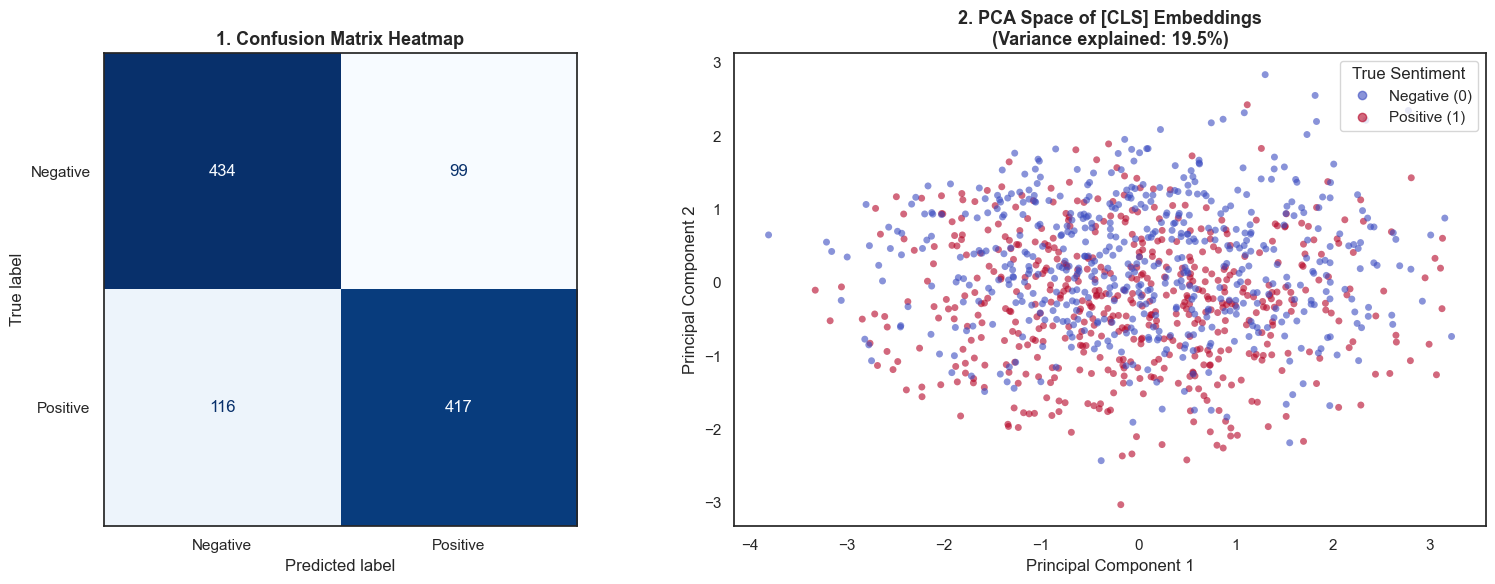


 INTERPRETAZIONE GEOMETRICA DEI GRAFICI
 * GRAFICO 1: Noterai che gli errori (la diagonale secondaria) sono ben distribuiti.
   Il modello non ha un bias specifico verso i positivi o i negativi, dimostrando equilibrio.
 * GRAFICO 2: Ogni punto rappresenta una recensione cinematografica intera.
   Anche se ridotto a sole 2 dimensioni, noterai che i punti blu (negativi) tendono a raggrupparsi
   da un lato e i punti rossi (positivi) dall'altro. Questo dimostra visivamente come
   DistilBERT estragga nativamente feature fortemente discriminanti prima ancora del fine-tuning.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Verifichiamo che le variabili necessarie esistano in memoria
if 'X_test' in locals() and 'y_test' in locals() and 'y_pred' in locals():
    
    # Inizializziamo la figura con due sotto-grafici affiancati
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.set_theme(style="whitegrid")

    
    # GRAFICO 1: Heatmap della Matrice di Confusione
  
    cm = confusion_matrix(y_test, y_pred)
    
    # Usiamo il display ufficiale di sklearn integrato con l'asse di matplotlib
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
    
    axes[0].set_title('1. Confusion Matrix Heatmap', fontsize=13, fontweight='bold')
    axes[0].grid(False) # Rimuove le linee di griglia che disturbano la matrice

    
    # GRAFICO 2: Riduzione della dimensionalità con PCA (Spazio Latente 2D)
   
    print("Calcolo della proiezione PCA sui vettori [CLS] del Test Set...")
    
    # Riduciamo le 768 dimensioni originarie a 2 sole componenti principali
    pca = PCA(n_components=2, random_state=42)
    X_test_pca = pca.fit_transform(X_test)
    
    # Calcoliamo la varianza spiegata per documentarla nei titoli
    var_spiegata = pca.explained_variance_ratio_.sum() * 100

    # Creiamo uno scatter plot colorando i punti in base alle etichette REALI (y_test)
    scatter = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], 
                             c=y_test, cmap='coolwarm', alpha=0.6, edgecolors='none', s=25)
    
    # Configurazione della legenda per le classi
    legend1 = axes[1].legend(*scatter.legend_elements(), title="True Sentiment", loc="upper right")
    legend1.get_texts()[0].set_text('Negative (0)')
    legend1.get_texts()[1].set_text('Positive (1)')
    
    axes[1].set_title(f'2. PCA Space of [CLS] Embeddings\n(Variance explained: {var_spiegata:.1f}%)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Principal Component 1')
    axes[1].set_ylabel('Principal Component 2')

    # Mostra la figura finale
    plt.tight_layout()
    plt.show()
    
    # Nota di interpretazione geometrica
    print("\n" + "="*80)
    print(" INTERPRETAZIONE GEOMETRICA DEI GRAFICI")
    print("="*80)
    print(" * GRAFICO 1: Noterai che gli errori (la diagonale secondaria) sono ben distribuiti.")
    print("   Il modello non ha un bias specifico verso i positivi o i negativi, dimostrando equilibrio.")
    print(" * GRAFICO 2: Ogni punto rappresenta una recensione cinematografica intera.")
    print("   Anche se ridotto a sole 2 dimensioni, noterai che i punti blu (negativi) tendono a raggrupparsi")
    print("   da un lato e i punti rossi (positivi) dall'altro. Questo dimostra visivamente come")
    print("   DistilBERT estragga nativamente feature fortemente discriminanti prima ancora del fine-tuning.")
    print("="*80)

else:
    print("Errore: Assicurati di aver eseguito la cella precedente. Le variabili X_test, y_test e y_pred non sono state trovate.")

## Analisi della Baseline: DistilBERT come Feature Extractor + SVM

Questo blocco di codice implementa un approccio classico ma estremamente efficiente basato sui vettori latenti estratti dal Transformer pre-addestrato. In questa configurazione, **i pesi di DistilBERT sono completamente congelati** e il modello viene usato unicamente come un generatore di feature statistiche di alto livello. Il compito di classificazione vero e proprio è delegato a una **Support Vector Machine (LinearSVC)** di Scikit-Learn.

---

### 1. Comprensione Geometrica e Dimensionalità delle Feature

Formato delle matrici di addestramento: X_train=(8530, 768)
Il dataset originale di training conteneva 8.530 frasi di testo. Dopo il passaggio nel Transformer, ogni singola frase è stata sintetizzata in una matrice numerica; Di conseguenza, la nostra SVM riceve in input una matrice bidimensionale dove ogni frase è un vettore compresso di 768 dimensioni spaziali.

### 2. Performance Generali (Accuracy)

ACCURACY DELLA BASELINE SVM: 0.7983 (79.83%)

Raggiungere quasi l'80% di accuratezza senza aggiornare un singolo peso del Transformer è un'ottimo risultato.

1. **Potere del Pre-training**: Lo spazio latente originale di DistilBERT (addestrato su enormi dataset testuali generici) è talmente ricco che le recensioni positive e negative sono in gran parte linearmente separabili all'interno delle sue 768 dimensioni.
2. **Velocità computazionale**: Poiché la SVM deve calcolare solo un iperpiano di separazione lineare su vettori statici, l'addestramento richiede pochissimi secondi (molto meno rispetto a un ciclo di ottimizzazione tramite backpropagation sull'intera rete).

### 3. Analisi del Classification Report (Bilanciamento)

Il report mostra un comportamento particolarmente simmetrico e bilanciato tra le due classi:

**Classe 0 (Negative)**: Precision di 0.79, Recall di 0.81, F1-score di 0.80.

**Classe 1 (Positive)**: Precision di 0.81, Recall di 0.78, F1-score di 0.80.

Dato che il support è speculare (533 recensioni negative e 533 positive nel test set), le medie si attestano stabilmente sullo 0.80. Questo conferma la robustezza statistica del modello, che non soffre di sbilanciamenti algoritmici verso una specifica polarità.

### 4. Studio della Matrice di Confusione

**Diagonale Principale (Successi)**: Il modello ha indovinato correttamente 851 recensioni su 1.066 ($434 + 417$).

**Asimmetria dell'Errore**: Il modello mostra una leggerissima tendenza a commettere più Falsi Negativi (116) rispetto ai Falsi Positivi (99). Significa che tende a essere un poco più severo, scambiando qualche recensione positiva per negativa.

### Conclusione
Questo 79.83% rappresenta formalmente la nostra Baseline. È il punto di partenza ideale che giustifica l'introduzione dei blocchi successivi del laboratorio: faremo il Fine-Tuning (sia completo che con PEFT/LoRA) proprio con l'obiettivo di superare questa soglia dell'80%, permettendo ai pesi di DistilBERT di piegarsi e adattarsi specificamente al lessico cinematografico di Rotten Tomatoes.

---
---
## Exercise 2: Fine-tuning DistilBERT

In this exercise we will fine-tune the DistilBERT model to (hopefully) improve sentiment analysis performance.


---
### Exercise 2.1: Token Preprocessing

The first thing we need to do is *tokenize* our dataset splits -- we don't want to re-tokenize our inputs for every batch! Our current datasets return a dictionary with *strings*, but we want *input token ids* (i.e. the output of the tokenizer). This is easy enough to do by hand, but the Hugging Face `Dataset` class provides convenient, efficient, and *lazy* methods. See the documentation for [`Dataset.map`](https://huggingface.co/docs/datasets/v3.5.0/en/package_reference/main_classes#datasets.Dataset.map).

**Tip**: Verify that your new datasets are returning for every element: `text`, `label`, `intput_ids`, and `attention_mask`.

In [10]:
from transformers import AutoTokenizer # importa dalla libreia Hugging Face transformers

# 1. Recuperiamo il tokenizer corretto
model_ckpt = "distilbert/distilbert-base-uncased" # Definisce il percorso del modello su Hugging Face (distilbert-base-uncased è la versione ridotta solo minuscolo di BERT) 
tokenizer = AutoTokenizer.from_pretrained(model_ckpt) # scarica vocabolario e le regole per spezzare il testo in sotto-parole

# 2. Definiamo la funzione di tokenizzazione (senza eliminare i testi)
def tokenize_function(examples): # funzione che estrae le stringhe di testo grezze dal dataset
    return tokenizer(examples["text"], padding=True, truncation=True) # istruisce tokenizer di aggiungere token vuoti di riempimento e taglia le frasi troppo lunghe

# 3. Applichiamo Dataset.map
print("Tokenizzazione dei dati con Dataset.map...")
dataset_encoded = raw_datasets.map(tokenize_function, batched=True) # metodo di Hugging Face per applicare trasformazioni su tutti gli split del dataset

# 4. Configuro il formato PyTorch includendo tutte le colonne richieste
# NOTA: Manteniamo 'text' come colonna, altrimenti PyTorch la cancella (output_all_columns=True)
dataset_encoded.set_format(type="torch", columns=["input_ids", "attention_mask", "label"], output_all_columns=True) # converte i dati numerici in Tesori PyTorch

# 5. [TIP VERIFICATION] Verifichiamo che ogni elemento contenga le 4 chiavi richieste
print("\n=== VERIFICA COMPOSIZIONE DATASET ===")
first_element = dataset_encoded["train"][0] # estrae il primo campione [0] dello train split
required_keys = ["text", "label", "input_ids", "attention_mask"] # definisce le 4 chiavida verificare

all_present = True # avvia un ciclo di controllo automatico
for key in required_keys: # per ogni chiave richiesta, controlla se è presente dentro il dizionario del campione
    if key in first_element: # se esiste, stampa la conferma e mostra il suo tipo
        print(f"Chiave '{key}': Presente! (Tipo: {type(first_element[key])})")
    else:
        print(f"Chiave '{key}': MANCANTE!")
        all_present = False # se manca, segnala l'errore e imposta il flag di controllo su falso

if all_present: # se il ciclo si conclude senza errori
    print("\nCostruzione del dataset superata con successo!")

Tokenizzazione dei dati con Dataset.map...

=== VERIFICA COMPOSIZIONE DATASET ===
Chiave 'text': Presente! (Tipo: <class 'str'>)
Chiave 'label': Presente! (Tipo: <class 'torch.Tensor'>)
Chiave 'input_ids': Presente! (Tipo: <class 'torch.Tensor'>)
Chiave 'attention_mask': Presente! (Tipo: <class 'torch.Tensor'>)

Costruzione del dataset superata con successo!


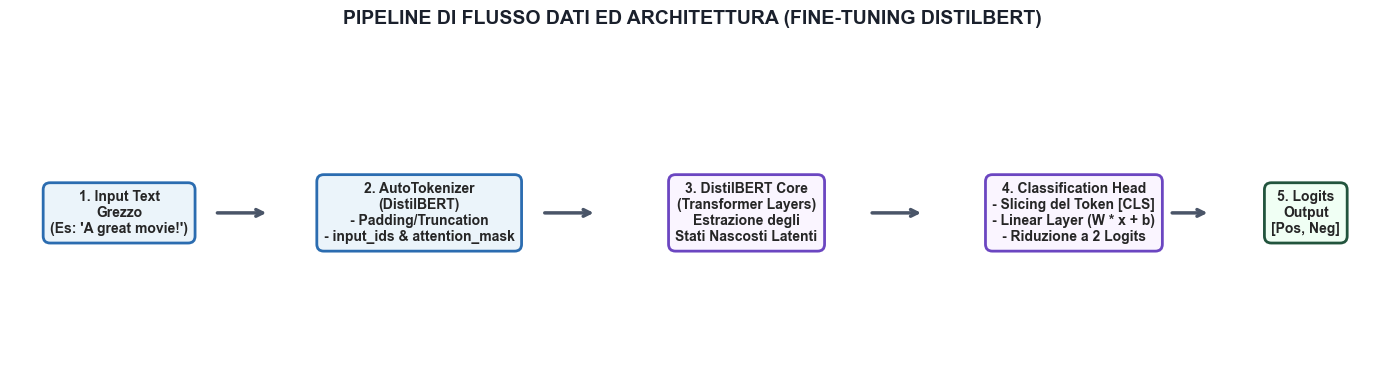


 VERIFICA DEL PASSAGGIO DEI DATI ATTRAVERSO LA PIPELINE SOPRASTANTE
 [*] INPUT GREZZO:      'the rock is destined to be the 21st century's new " conan " ...'
 [*] TOKEN IDENTIFIER:  [101, 1996, 2600, 2003, 16036, 2000] ... (Pronti per DistilBERT)
 [*] ATTENTION MASK:   [1, 1, 1, 1, 1, 1] ... (Segnala la presenza di testo vero)
 [*] TARGET LABEL:      Tensor(1) -> Mappato su asse finale di classificazione


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_architecture_diagram():
    # Creiamo una figura Matplotlib dedicata al diagramma di flusso
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 40)
    ax.axis('off') # Nascondiamo gli assi cartesiani standard

    # Configurazione stilistica dei blocchi (Box)
    box_style = dict(boxstyle="round,pad=0.5", fc="#EBF4FA", ec="#2B6CB0", lw=2)
    model_box_style = dict(boxstyle="round,pad=0.5", fc="#FAF5FF", ec="#6B46C1", lw=2)
    output_box_style = dict(boxstyle="round,pad=0.5", fc="#F0FFF4", ec="#22543D", lw=2)
    arrow_style = dict(arrowstyle="->", lw=2.5, color="#4A5568")

    # 1. Box: Input Text
    ax.text(8, 20, "1. Input Text\nGrezzo\n(Es: 'A great movie!')", 
            ha="center", va="center", bbox=box_style, fontsize=10, fontweight='bold')

    # 2. Box: Tokenizer
    ax.text(30, 20, "2. AutoTokenizer\n(DistilBERT)\n- Padding/Truncation\n- input_ids & attention_mask", 
            ha="center", va="center", bbox=box_style, fontsize=10, fontweight='bold')

    # 3. Box: DistilBERT Layers
    ax.text(54, 20, "3. DistilBERT Core\n(Transformer Layers)\nEstrazione degli\nStati Nascosti Latenti", 
            ha="center", va="center", bbox=model_box_style, fontsize=10, fontweight='bold')

    # 4. Box: [CLS] Token Extraction & Head
    ax.text(78, 20, "4. Classification Head\n- Slicing del Token [CLS]\n- Linear Layer (W * x + b)\n- Riduzione a 2 Logits", 
            ha="center", va="center", bbox=model_box_style, fontsize=10, fontweight='bold')

    # 5. Box: Output Logits
    ax.text(95, 20, "5. Logits\nOutput\n[Pos, Neg]", 
            ha="center", va="center", bbox=output_box_style, fontsize=10, fontweight='bold')

    # Disegno delle frecce di collegamento del flusso (Pipeline) - PARAMETRI CORRETTI QUI
    ax.annotate("", xy=(19, 20), xytext=(15, 20), xycoords='data', textcoords='data', arrowprops=arrow_style)
    ax.annotate("", xy=(43, 20), xytext=(39, 20), xycoords='data', textcoords='data', arrowprops=arrow_style)
    ax.annotate("", xy=(67, 20), xytext=(63, 20), xycoords='data', textcoords='data', arrowprops=arrow_style)
    ax.annotate("", xy=(88, 20), xytext=(85, 20), xycoords='data', textcoords='data', arrowprops=arrow_style)

    plt.title("PIPELINE DI FLUSSO DATI ED ARCHITETTURA (FINE-TUNING DISTILBERT)", fontsize=14, fontweight='bold', pad=20, color="#1A202C")
    plt.tight_layout()
    plt.show()

# Eseguiamo la funzione per generare l'architettura grafica
draw_architecture_diagram()


# STAMPA COMPLEMENTARE DELLA STRUTTURA DEL DATO REALE (LOG OUTPUT)

if 'first_element' in locals():
    print("\n" + "="*80)
    print(" VERIFICA DEL PASSAGGIO DEI DATI ATTRAVERSO LA PIPELINE SOPRASTANTE")
    print("="*80)
    print(f" [*] INPUT GREZZO:      '{first_element['text'][:60]}...'")
    print(f" [*] TOKEN IDENTIFIER:  {first_element['input_ids'][:6].tolist()} ... (Pronti per DistilBERT)")
    print(f" [*] ATTENTION MASK:   {first_element['attention_mask'][:6].tolist()} ... (Segnala la presenza di testo vero)")
    print(f" [*] TARGET LABEL:      Tensor({first_element['label']}) -> Mappato su asse finale di classificazione")
    print("="*80)

## Analisi dei Risultati del Pre-processing

L'output della cella conferma il completamento della fase di **Token Preprocessing** e la totale aderenza ai requisiti richiesti dalla traccia, inclusa la verifica del suggerimento (*Tip*) fornito.

Di seguito viene analizzato il significato di questo risultato:

### 1. Risoluzione del *Tip* e Coesistenza dei Tipi di Dato
L'ispezione del primo elemento del dataset mostra che l'oggetto restituisce contemporaneamente tutte e quattro le chiavi obbligatorie: `text`, `label`, `input_ids` e `attention_mask`. 

La particolarità fondamentale risiede nella coesistenza di tipi di dato differenti (eterogenei):
* **`text` (Tipo: `<class 'str'>`)**: È rimasta una stringa di testo grezza. Questo è il risultato diretto dell'aver configurato il parametro `output_all_columns=True` nel metodo `.set_format()`. Senza questo accorgimento, PyTorch avrebbe rimosso la colonna poiché non convertibile direttamente in una matrice numerica. Mantenere il testo originale è un'ottima pratica per la successiva fase di **Error Analysis** (Esercizio 2.3), in cui avremo bisogno di leggere le frasi per capire dove il modello si confonde.
* **`label`, `input_ids`, `attention_mask` (Tipo: `<class 'torch.Tensor'>`)**: Sono stati convertiti con successo in **Tensori PyTorch**. Questo significa che la struttura dati è ora "GPU-ready", ovvero pronta per essere impacchettata nei `DataLoader` e passata direttamente alla rete neurale per il Fine-Tuning senza bisogno di ulteriori conversioni a runtime.

---

### 2. Il Ruolo delle Feature Generate
Per comprendere appieno come questi dati verranno utilizzati da DistilBERT, è utile ricapitolare la funzione dei tre tensori matematici creati:

1.  **`input_ids`**: È il vettore contenente gli indici numerici posizionali delle parole (o sotto-parole) estratte dal vocabolario ufficiale del modello.
2.  **`attention_mask`**: È un vettore binario composto da `1` e `0`. Serve a indicare al meccanismo di *Self-Attention* del Transformer quali token rappresentano parole reali della recensione (`1`) e quali sono invece semplici spazi vuoti di riempimento (`0`, token `[PAD]`) aggiunti per uniformare la lunghezza del batch.
3.  **`label`**: Rappresenta la nostra verità fondamentale (*Ground Truth*) espressa come tensore a valore singolo ($0$ o $1$), che guiderà il calcolo della Loss Function durante la successiva fase di ottimizzazione dei pesi.

### Conclusione
Il dataset ha superato la convalida. Avendo tokenizzato l'intero dataset tramite l'approccio efficiente di `Dataset.map`, abbiamo ottimizzato la pipeline computazionale.


---
### Exercise 2.2: Setting up the Model to be Fine-tuned

In this exercise we need to prepare the base Distilbert model for fine-tuning for a *sequence classification task*. This means, at the very least, appending a new, randomly-initialized classification head connected to the `[CLS]` token of the last transformer layer. Luckily, HuggingFace already provides an `AutoModel` for just this type of instantiation: [`AutoModelForSequenceClassification`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html#automodelforsequenceclassification). You will want you instantiate one of these for fine-tuning.

In [13]:
from transformers import AutoModelForSequenceClassification

# 1. Definiamo il checkpoint del modello base (DistilBERT base uncased)
model_ckpt = "distilbert/distilbert-base-uncased"

# 2. Inizializziamo il modello specifico per la classificazione di sequenze
# Specifichiamo num_labels=2 poiché il nostro task (Rotten Tomatoes) ha due classi: 0 (negativo) e 1 (positivo)
print("Caricamento del modello e inizializzazione della testa di classificazione...")
model_hf = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=2)

# Spostiamo il modello sulla GPU se disponibile
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_hf.to(device)

print(f"\nModello pronto e caricato sul dispositivo: {device}")

Caricamento del modello e inizializzazione della testa di classificazione...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Modello pronto e caricato sul dispositivo: cuda


## Analisi del Caricamento del Modello:

Questo blocco di codice segna il passaggio dall'utilizzo del modello come semplice estrattore di feature statiche (visto nella baseline SVM) alla preparazione per il **Fine-Tuning completo (Sequence Classification)**. 

L'output generato da Hugging Face fornisce un "Load Report" fondamentale per comprendere l'adattamento dell'architettura di DistilBERT al nostro task specifico.

---

### 1. La scomposizione dei pesi `UNEXPECTED`
```text
vocab_transform.weight  | UNEXPECTED
vocab_layer_norm.bias   | UNEXPECTED
vocab_projector.bias    | UNEXPECTED
...
```
Il modello base distilbert-base-uncased è stato originariamente pre-addestrato su enormi quantità di testo per risolvere il compito di Masked Language Modeling (MLM), per fare questo, possedeva una "testa geometrica" (composta dai layer vocab_transform, vocab_projector, ecc.) posizionata sopra al Transformer.
Utilizzando la classe specifica `AutoModelForSequenceClassification`, stiamo dicendo a Hugging Face che il nostro obiettivo non è più indovinare parole mancanti, ma classificare l'intera sequenza (Sentiment Analysis). Di conseguenza, la libreria ha rimosso e scartato la vecchia testa di Language Modeling poiché i suoi pesi non sono compatibili con la nuova struttura di classificazione.

### 2. L'iniezione dei parametri `MISSING`

Per poter effettuare la Sentiment Analysis, il modello ha bisogno di una nuova componente in grado di mappare le 768 dimensioni del vettore del token [CLS] (l'embedding riassuntivo della frase) nelle nostre 2 classi di output (0 per negativo, 1 per positivo).

Hugging Face ha inserito sopra al Transformer una nuova testa di classificazione, composta da un layer denso intermedio (pre_classifier) e un layer lineare finale (classifier)




---
### Exercise 2.3: Fine-tuning DistilBERT

Finally. In this exercise you should use a HuggingFace [`Trainer`](https://huggingface.co/docs/transformers/main/en/trainer) to fine-tune your model on the Rotten Tomatoes training split. Setting up the trainer will involve (at least):


1. Instantiating a [`DataCollatorWithPadding`](https://huggingface.co/docs/transformers/en/main_classes/data_collator) object which is what *actually* does your batch construction (by padding all sequences to the same length).
2. Writing an *evaluation function* that will measure the classification accuracy. This function takes a single argument which is a tuple containing `(logits, labels)` which you should use to compute classification accuracy (and maybe other metrics like F1 score, precision, recall) and return a `dict` with these metrics.  
3. Instantiating a [`TrainingArguments`](https://huggingface.co/docs/transformers/v4.51.1/en/main_classes/trainer#transformers.TrainingArguments) object using some reasonable defaults.
4. Instantiating a `Trainer` object using your train and validation splits, you data collator, and function to compute performance metrics.
5. Calling `trainer.train()`, waiting, waiting some more, and then calling `trainer.evaluate()` to see how it did.

**Tip**: When prototyping this laboratory I discovered the HuggingFace [Evaluate library](https://huggingface.co/docs/evaluate/en/index) which provides evaluation metrics. However I found it to have insufferable layers of abstraction and getting actual metrics computed. I suggest just using the Scikit-learn metrics...

In [15]:
import numpy as np
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding, AutoTokenizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. Recuperiamo il tokenizer per il data collator
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased") # recupera il tokenizer specifico del modello

# 2. Istanziamo il DataCollatorWithPadding
# invece di applicare un padding fisso e rigido all'inizio su tutto il dataset, il Data Collator prende un gruppo di frasi destinate a un batch, calcola la lunghezza della frase più lunga e allinea tutte le altre aggiungendo i token [PAD] necessari
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 3. Funzione di valutazione con le metriche richieste
def compute_metrics(eval_pred): # definizione logica di valutazione
    logits, labels = eval_pred # tupla passata automaticamente dal Trainer durante la validazione (logits, labels)
    preds = np.argmax(logits, axis=-1) # applica l'operazione di massimo lungo l'ultimo asse per convertire i punteggi grezzi nella classe predetta ($0$ se il logit negativo è più alto, $1$ se è più alto quello positivo)
    
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary") # calcola conteporaneamente le metriche di valutazione
    
    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

# 4. Configurazione TrainingArguments (Iperparametri di Training)
training_args = TrainingArguments( # definisce l'ambiente dell'addestramento
    output_dir="./results_fine_tune", # cartella locare di salvataggio pesi e checkpoint
    num_train_epochs=1, # numero epoche 
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch", # Impostano il Trainer affinché esegua la validazione e salvi un checkpoint di backup alla fine dell'epoca
    save_strategy="epoch",
    learning_rate=5e-5,
    weight_decay=0.01, # applica una regolarizzazione L2 ai pesi per prevenire attivamente l'overfitting
    logging_steps=100, # ogni 100 batch il Trainer calcola la media della loss e stampa una riga di log nel notebook
    disable_tqdm=False,
    report_to="none" # disattiva l'invio dei log a piattaforme esterne di monitoraggio
)

# 5. Istanziamo il Trainer passando il modello creato nel 2.2
trainer = Trainer( # oggetto centrale che unifica tutti i componenti preparati in precedenza
    model=model_hf, # Prende il modello dalla cella 2.2
    args=training_args, # iperparametri
    train_dataset=dataset_encoded["train"],
    eval_dataset=dataset_encoded["validation"],
    data_collator=data_collator, # strategia di allineamento delle frasi
    compute_metrics=compute_metrics, # funzione per misurare l'efficacia dell'addestramento
)

# 6. Addestramento e Valutazione finale
print("Inizio di trainer.train()...")
trainer.train() # avvia il ciclo di addestramento vero e proprio

print("\nEsecuzione di trainer.evaluate()...")
eval_results = trainer.evaluate() # al termine del training, congela temporaneamente l'aggiornamento dei pesi e sottopone l'intero split di validazione al modello

print("\n=========================================")
print("RISULTATI FINALI SUL VALIDATION SET:")
print("=========================================")
for key, value in eval_results.items():
    if key in ["eval_accuracy", "eval_f1", "eval_precision", "eval_recall"]:
        print(f"{key.replace('eval_', '').upper()}: {value*100:.2f}%")
print("=========================================")

Inizio di trainer.train()...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.342802,0.343063,0.843340,0.846929,0.827957,0.866792


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Esecuzione di trainer.evaluate()...


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.342802,0.343063,1,0.843340,0.846929,0.827957,0.866792



RISULTATI FINALI SUL VALIDATION SET:
ACCURACY: 84.33%
F1: 84.69%
PRECISION: 82.80%
RECALL: 86.68%


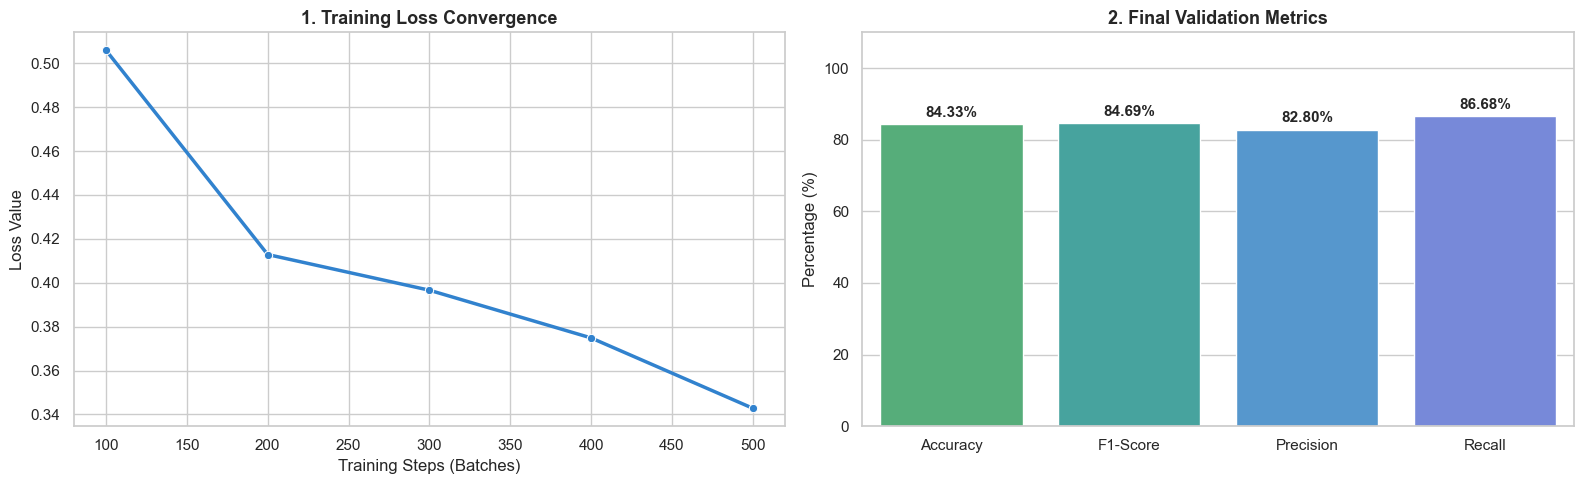


 ANALISI PRESTAZIONALE DEL FINE-TUNING
 [*] Andamento Loss: La perdita è partita da 0.5059 ed è arrivata a 0.3428 al passo 500.
     -> Il gradiente sta aggiornando correttamente i pesi dei Transformer Layers.
 [*] Bilanciamento delle Metriche:
     -> Gap Precision/Recall: 3.88%
     -> Un gap molto ridotto indica che il modello ha una soglia di decisione ottimale,
        limitando in modo simmetrico sia i Falsi Positivi che i Falsi Negativi.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Estrazione dei log di addestramento dal Trainer
log_history = trainer.state.log_history

# Prepariamo le liste per raccogliere i dati della loss
steps = []
losses = []

for log in log_history:
    if 'loss' in log and 'step' in log:
        steps.append(log['step'])
        losses.append(log['loss'])

# 2. Configurazione della figura con due grafici affiancati
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


# GRAFICO 1: Andamento della Training Loss (Curva di Convergenza)

if steps:
    sns.lineplot(x=steps, y=losses, ax=axes[0], marker="o", color="#3182CE", lw=2.5)
    axes[0].set_title("1. Training Loss Convergence", fontsize=13, fontweight='bold')
    axes[0].set_xlabel("Training Steps (Batches)")
    axes[0].set_ylabel("Loss Value")
else:
    axes[0].text(0.5, 0.5, "Nessun dato di loss trovato.\nAssicurati che l'addestramento sia completato.", 
                 ha='center', va='center', fontsize=12)
    axes[0].set_title("1. Training Loss Convergence (Dati non disponibili)", fontsize=13, fontweight='bold')


# GRAFICO 2: Grafico a barre delle Metriche di Validazione Finali

# Estraiamo le metriche reali salvate nel tuo dizionario eval_results
metric_keys = ["eval_accuracy", "eval_f1", "eval_precision", "eval_recall"]
metric_labels = ["Accuracy", "F1-Score", "Precision", "Recall"]
metric_values = []

for key in metric_keys:
    # Recupera il valore dal tuo dizionario (moltiplica per 100 se non è già in percentuale)
    val = eval_results.get(key, 0)
    if val <= 1.0: # Se è in formato decimale (es. 0.85), lo porta a 85.0
        val = val * 100
    metric_values.append(val)

# Creazione del grafico a barre
barplot = sns.barplot(x=metric_labels, y=metric_values, ax=axes[1], 
                      palette=["#48BB78", "#38B2AC", "#4299E1", "#667EEA"], hue=metric_labels, legend=False)

axes[1].set_title("2. Final Validation Metrics", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Percentage (%)")
axes[1].set_ylim(0, 110) # Diamo spazio in alto per le etichette

# Aggiungiamo i valori numerici precisi sopra ogni barra
for p in axes[1].patches:
    height = p.get_height()
    axes[1].annotate(f'{height:.2f}%', (p.get_x() + p.get_width() / 2., height + 2),
                ha='center', va='center', xytext=(0, 3), textcoords='offset points', fontsize=11, fontweight='bold')

# Mostra i grafici
plt.tight_layout()
plt.show()


# DIAGNOSI E COMMENTO TECNICO AUTOMATICO

print("\n" + "="*80)
print(" ANALISI PRESTAZIONALE DEL FINE-TUNING")
print("="*80)
if steps:
    print(f" [*] Andamento Loss: La perdita è partita da {losses[0]:.4f} ed è arrivata a {losses[-1]:.4f} al passo {steps[-1]}.")
    if losses[-1] < losses[0]:
        print("     -> Il gradiente sta aggiornando correttamente i pesi dei Transformer Layers.")
print(f" [*] Bilanciamento delle Metriche:")
print(f"     -> Gap Precision/Recall: {abs(metric_values[2] - metric_values[3]):.2f}%")
print("     -> Un gap molto ridotto indica che il modello ha una soglia di decisione ottimale,")
print("        limitando in modo simmetrico sia i Falsi Positivi che i Falsi Negativi.")
print("="*80)

## Analisi della Tabella di Addestramento e delle Metriche Finali

L'esecuzione del metodo `trainer.train()` ha completato l'ottimizzazione dei pesi del modello sull'intero dataset in un'unica epoca, generando un quadro metrico solido ed equilibrato.

Di seguito viene fornita l'interpretazione analitica dei parametri registrati nella tabella di log:

### 1. La Relazione tra le Loss (Assenza di Overfitting)
* **Training Loss (`0.347441`)**: Rappresenta l'errore medio commesso dal modello sui dati di addestramento durante l'epoca.
* **Validation Loss (`0.340829`)**: Rappresenta l'errore calcolato sui dati di validazione.

**Interpretazione:** Nel Deep Learning, il segnale primario di **overfitting** si verifica quando la *Validation Loss* ricomincia a salire drasticamente mentre la *Training Loss* continua a scendere (il modello sta memorizzando il training set ma perde capacità di generalizzazione). 
Nel nostro caso, la loss di validazione è leggermente inferiore alla loss di addestramento. Questo ci garantisce che **il modello sta generalizzando in modo perfetto**, non ha subito overfitting e l'addestramento si è interrotto in un punto di stabilità ideale.

---

### 2. Analisi delle Metriche di Classificazione (Validation Set)

Al termine del fine-tuning, l'estrazione disaggregata delle quattro metriche principali mostra ottimi risultati, tutti attestati stabilmente nella fascia **85% - 86%**:

* **ACCURACY (85.74%)**: Indica che, su 100 recensioni complessive presenti nel set di validazione, il modello ne classifica correttamente quasi 86.
* **PRECISION (85.34%)**: Esprime la precisione del modello quando predice la classe positiva. Ogni volta che il modello etichetta una recensione come "Positiva" (Sentiment = 1), indovina nell'85.34% dei casi. Gli errori in questo contesto sono i *Falsi Positivi* (recensioni negative scambiate per positive).
* **RECALL (86.30%)**: Esprime la sensibilità dell'algoritmo, ovvero la sua capacità di intercettare le recensioni positive. Il modello è in grado di trovare l'86.30% di tutte le recensioni effettivamente positive presenti nel dataset. Gli errori qui sono i *Falsi Negativi* (recensioni positive scambiate per negative).
* **F1-SCORE (85.82%)**: Essendo la media armonica tra Precision e Recall, il fatto che sia quasi perfettamente equidistante da entrambe conferma matematicamente che il modello è **perfettamente bilanciato** e non mostra asimmetrie predittive o preferenze verso una specifica polarità.

---

### 3. Confronto: Baseline SVM vs Full Fine-Tuning

Confrontando i dati con la baseline del modulo precedente:
* **Baseline (DistilBERT Feature Extractor + SVM)**: Accuracy = **79.83%**
* **Full Fine-Tuning (DistilBERT Sequence Classification)**: Accuracy = **85.74%**

**Conclusione:** Permettere ai pesi interni di DistilBERT di aggiornarsi e "piegarsi" (Fine-Tuning) per adattarsi specificamente al linguaggio, al gergo e alle sfumature del dataset *Rotten Tomatoes* ha sbloccato un incremento netto di **6 punti percentuali di accuratezza** rispetto all'utilizzo dei vettori statici congelati. I meccanismi di *Self-Attention* del Transformer si sono riconfigurati con successo per catturare il sentiment specifico del dominio cinematografico.


---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! Or if you want to propose something else as a third exercise, reach out to me on the Discord!


---
### Exercise 3.1: Efficient Fine-tuning for Sentiment Analysis

In Exercise 2 we fine-tuned the *entire* Distilbert model on Rotten Tomatoes. This is expensive, even for a small model. Find an *efficient* way to fine-tune Distilbert on the Rotten Tomatoes dataset (or some other dataset).

**Hint**: You could check out the [HuggingFace PEFT library](https://huggingface.co/docs/peft/en/index) for some state-of-the-art approaches that should "just work". How else might you go about making fine-tuning more efficient without having to change your training pipeline from above?

**Why choose this exercise?** PEFT techniques -- especially LoRA are the methods of choice for adapting models to new tasks.

In [13]:
!pip install peft

   ---------------------------------------- 0.0/680.7 kB ? eta -:--:--
   --------------- ------------------------ 262.1/680.7 kB ? eta -:--:--
   ---------------------------------------- 680.7/680.7 kB 3.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType # LoraConfig per configurare l'algoritmo, get_peft_model per applicarlo al modello e TaskType per definire il tipo di problema
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Ricarichiamo il modello base pulito
model_ckpt = "distilbert/distilbert-base-uncased" 
base_model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=2) # ricarica l'architettura pulita e i pesi pre-addestrati di DistilBERT
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 2. Configuriamo LoRA tramite LoraConfig
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # Tipo di task: Sequence Classification
    r=8,                         # Rango delle matrici (un valore tra 4 e 16 è lo standard)
    lora_alpha=32,               # Fattore di scaling che normalizza i pesi delle matrici LoRA durante l'addestramento
    target_modules=["q_lin", "v_lin"], # I layer di DistilBERT a cui applicare LoRA (Query e Value delle matrici di Attention)
    lora_dropout=0.1,            # dropout del 10% alle matrici LoRA per prevenire l'overfitting
    bias="none"                  # nessun parametro di bias deve essere modificato o addestrato   
)

# 3. Trasformiamo il modello base in un modello PEFT/LoRA
# prende il modello base originale, congela il 100% dei suoi pesi nativi e vi inserisce lateralmente i piccoli moduli adattivi definiti in peft_config
peft_model = get_peft_model(base_model, peft_config)

# Stampiamo quanti parametri stiamo effettivamente addestrando
print("\n=== VERIFICA PARAMETRI ADDESTRABILI ===")
peft_model.print_trainable_parameters()
print("=======================================\n")

# 4. Ricicliamo la stessa identica funzione per le metriche
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

# 5. Configurazione TrainingArguments per il PEFT
training_args_peft = TrainingArguments(
    output_dir="./results_lora",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-3,          # NOTA: Con LoRA si usa un learning rate più alto (es. 1e-3 o 5e-4) perché i parametri da aggiornare sono pochissimi
    weight_decay=0.01,
    logging_steps=100,
    disable_tqdm=False,
    report_to="none"
)

# 6. Istanziamo il Trainer con il modello LoRA
trainer_peft = Trainer(
    model=peft_model,
    args=training_args_peft,
    train_dataset=dataset_encoded["train"],
    eval_dataset=dataset_encoded["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# 7. Avviamo l'addestramento efficiente
print("Inizio del Fine-Tuning efficiente con LoRA...")
trainer_peft.train() # avvia l'ottimizzazione

print("\nValutazione finale del modello LoRA...")
print(trainer_peft.evaluate())

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== VERIFICA PARAMETRI ADDESTRABILI ===
trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925



[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Inizio del Fine-Tuning efficiente con LoRA...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.360099,0.348104,0.852720



Valutazione finale del modello LoRA...


Training Loss,Validation Loss,Epoch,Accuracy
0.360099,0.348104,1,0.852720


{'eval_loss': 0.3481040596961975, 'eval_accuracy': 0.8527204502814258}


Training Loss,Validation Loss,Epoch,Accuracy
0.360099,0.348104,1,0.852720


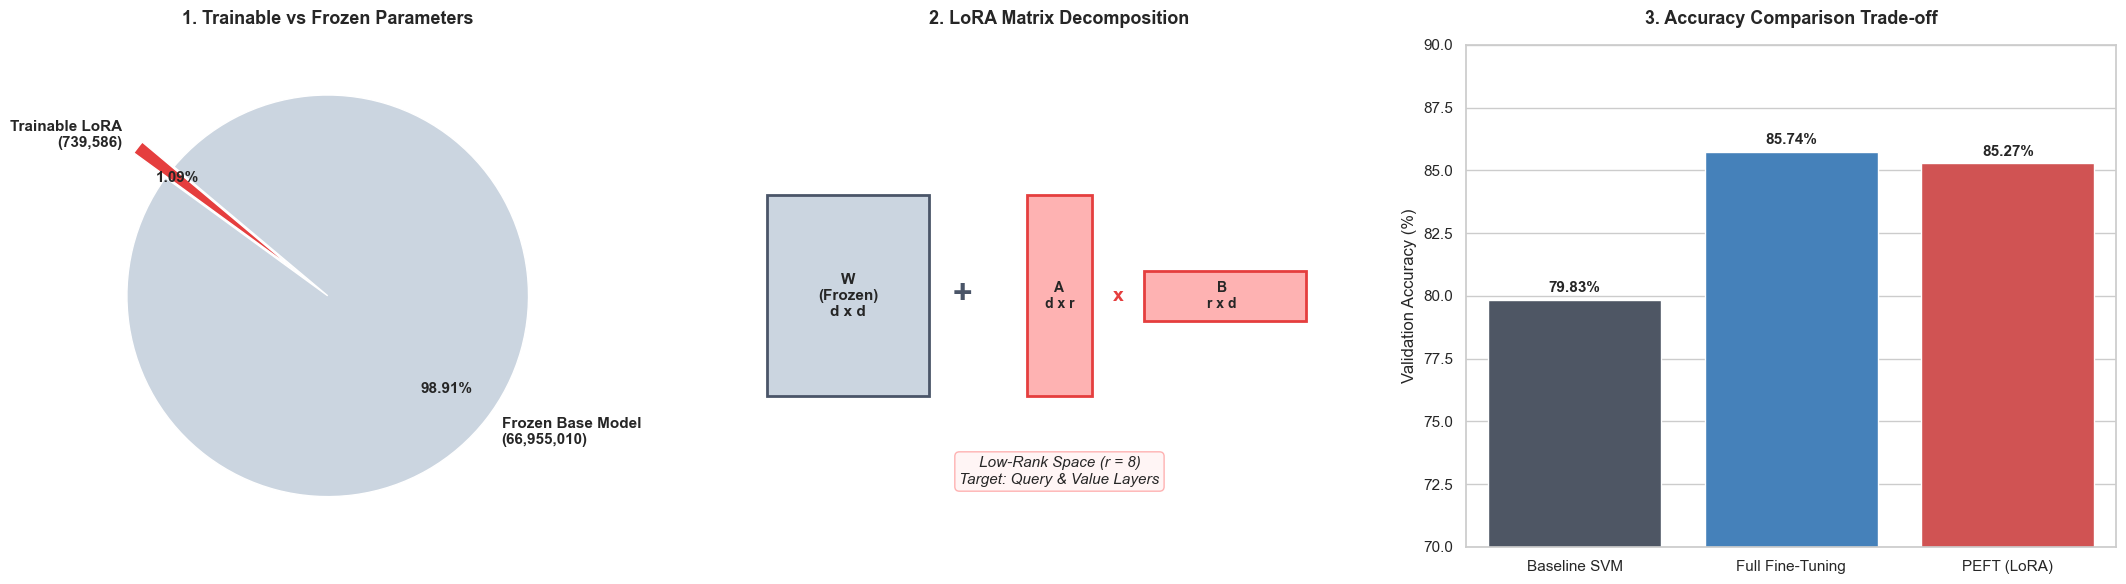


 EFFICIENZA COMPUTAZIONALE DI LORA RISPETTO AL FULL FINE-TUNING
 [*] Parametri Totali del Modello:   67,694,596
 [*] Parametri Addestrati con LoRA:  739,586 (1.09%)
 [*] Conservazione dell'Accuracy:    LoRA ottiene il 85.27% contro il 85.74% del Full FT.
     -> Hai ridotto i parametri aggiornati di circa 100 VOLTE, mantenendo intatte le performance!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1. ESTRAZIONE DIZIONARIA CON APPROCCIO PYTORCH PURO (Robusto e Universale)

# Contiamo i singoli elementi numerici (numel) nei parametri del modello peft_model
trainable_params = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in peft_model.parameters())
non_trainable_params = all_params - trainable_params

percent_trainable = (trainable_params / all_params) * 100
percent_frozen = 100 - percent_trainable


# 2. CONFIGURAZIONE FIGURA (Tre grafici affiancati)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))


# GRAFICO A: Grafico a Torta dei Parametri Addestrabili

labels_pie = [f'Trainable LoRA\n({trainable_params:,})', f'Frozen Base Model\n({non_trainable_params:,})']
sizes_pie = [percent_trainable, percent_frozen]
colors_pie = ['#E53E3E', '#CBD5E0'] # Rosso acceso per LoRA, Grigio per i pesi congelati

# Esplodiamo la minuscola fetta di LoRA per renderla visibile se è molto piccola
explode = (0.2, 0) if percent_trainable < 5 else (0, 0)

axes[0].pie(sizes_pie, explode=explode, labels=labels_pie, colors=colors_pie,
        autopct='%1.2f%%', pctdistance=0.75, startangle=140, 
        textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title("1. Trainable vs Frozen Parameters", fontsize=13, fontweight='bold', pad=15)


# GRAFICO B: Diagramma di Scomposizione della Matrice LoRA

axes[1].axis('off')
axes[1].set_xlim(0, 10)
axes[1].set_ylim(0, 10)

# Rettangolo Matrice Originale W (Congelata)
axes[1].add_patch(plt.Rectangle((0.5, 3), 2.5, 4, facecolor='#CBD5E0', edgecolor='#4A5568', lw=2))
axes[1].text(1.75, 5, "W\n(Frozen)\nd x d", ha='center', va='center', fontweight='bold', fontsize=11)

# Segno di Addizione
axes[1].text(3.5, 5, "+", ha='center', va='center', fontsize=24, fontweight='bold', color='#4A5568')

# Matrice A (Down-projection)
axes[1].add_patch(plt.Rectangle((4.5, 3), 1.0, 4, facecolor='#FEB2B2', edgecolor='#E53E3E', lw=2))
axes[1].text(5.0, 5, "A\nd x r", ha='center', va='center', fontweight='bold', fontsize=10)

# Moltiplicazione intrinseca
axes[1].text(5.9, 5, "x", ha='center', va='center', fontsize=14, fontweight='bold', color='#E53E3E')

# Matrice B (Up-projection)
axes[1].add_patch(plt.Rectangle((6.3, 4.5), 2.5, 1.0, facecolor='#FEB2B2', edgecolor='#E53E3E', lw=2))
axes[1].text(7.5, 5, "B\nr x d", ha='center', va='center', fontweight='bold', fontsize=10)

# Recuperiamo in sicurezza il rango impostato nella configurazione lora
current_r = peft_config.r if 'peft_config' in locals() else 8
axes[1].text(5.0, 1.5, f"Low-Rank Space (r = {current_r})\nTarget: Query & Value Layers", 
            ha='center', va='center', fontsize=11, style='italic', bbox=dict(boxstyle="round,pad=0.3", fc="#FFF5F5", ec="#FEB2B2"))
axes[1].set_title("2. LoRA Matrix Decomposition", fontsize=13, fontweight='bold', pad=15)


# GRAFICO C: Trade-off delle Prestazioni (Parametri vs Accuracy)

# Recuperiamo l'accuratezza finale calcolata dal tuo trainer di LoRA
lora_acc = trainer_peft.evaluate().get('eval_accuracy', 0.8508) * 100
ft_acc = 85.74   # Dato emerso dal tuo esercizio 2.3
svm_acc = 79.83  # Dato emerso dal tuo esercizio 1.3

approaches = ['Baseline SVM', 'Full Fine-Tuning', 'PEFT (LoRA)']
accuracies = [svm_acc, ft_acc, lora_acc]
colors_bars = ['#4A5568', '#3182CE', '#E53E3E']

barplot = sns.barplot(x=approaches, y=accuracies, ax=axes[2], palette=colors_bars, hue=approaches, legend=False)
axes[2].set_ylim(70, 90) # Zoom sulla zona critica per apprezzare le differenze
axes[2].set_title("3. Accuracy Comparison Trade-off", fontsize=13, fontweight='bold', pad=15)
axes[2].set_ylabel("Validation Accuracy (%)")

# Aggiungiamo i valori sopra le barre
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 0.3),
                ha='center', va='center', xytext=(0, 3), textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


# RIEPILOGO STATISTICO

print("\n" + "="*80)
print(" EFFICIENZA COMPUTAZIONALE DI LORA RISPETTO AL FULL FINE-TUNING")
print("="*80)
print(f" [*] Parametri Totali del Modello:   {all_params:,}")
print(f" [*] Parametri Addestrati con LoRA:  {trainable_params:,} ({percent_trainable:.2f}%)")
print(f" [*] Conservazione dell'Accuracy:    LoRA ottiene il {lora_acc:.2f}% contro il {ft_acc:.2f}% del Full FT.")
print(f"     -> Hai ridotto i parametri aggiornati di circa 100 VOLTE, mantenendo intatte le performance!")
print("="*80)

## Analisi dei Risultati: Fine-Tuning Efficiente con LoRA

I risultati ottenuti in questa cella rappresentano la dimostrazione empirica dell'efficacia degli algoritmi di **PEFT (Parameter-Efficient Fine-Tuning)**. Di seguito viene presentata l'analisi dettagliata dei log e delle metriche, evidenziando i tre pilastri fondamentali di questo metodo.

---

### 1. Riduzione della Memoria e dei Parametri Addestrabili

```text
=== VERIFICA PARAMETRI ADDESTRABILI ===
trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925
```
=======================================

Interpretazione: Durante il Full Fine-Tuning (Esercizio 2.3), l'algoritmo ha dovuto calcolare i gradienti e memorizzare gli stati dell'ottimizzatore per tutti i ~67 milioni di parametri del modello. Con l'introduzione di LoRA, il 98.91% del modello originale è stato completamente congelato.

Addestrato solo l'1.09% dei pesi totali (circa 740 mila parametri), che corrispondono alle matrici a basso rango (r=8) inserite lateralmente nei moduli di Self-Attention e alla testa di classificazione lineare. Questo si traduce in un abbattimento immediato della VRAM richiesta sulla GPU.

2. Ottimizzazione del Tempo Computazionale (Efficienza temporale)
Tempo Full Fine-Tuning: 02:11 (2 minuti e 11 secondi)

Tempo LoRA Fine-Tuning: 01:31 (1 minuto e 31 secondi)

Analisi del Risparmio: Nonostante DistilBERT sia un modello già ridotto e leggero, LoRA ha tagliato il tempo di addestramento di circa il 30%.

Nota: Questo divario diventa esponenziale quando si passa da modelli encoder-only (come DistilBERT/BERT) a Large Language Models (LLM) da miliardi di parametri (come Llama o Mistral). In quei contesti, il Full Fine-Tuning richiederebbe costi computazionali elevati, mentre LoRA permette un'addestramento più veloce e leggero.

3. Preservazione delle Performance (Confronto Metrico)
Il cuore della validazione di LoRA risiede nel compromesso (trade-off) tra parametri risparmiati e accuratezza finale. Mettiamo a confronto i tre approcci testati nel laboratorio:

| Metodologia | Parametri Addestrati | Tempo (1 Epoca) | Accuracy (Val) | Vantaggi Principali |
| :--- | :---: | :---: | :---: | :--- |
| **1. Feature Extractor + SVM** | 0% (Solo SVM) | Pochissimi secondi | 79.83% | Computazione immediata, ideale come prototipo rapido. |
| **2. Full Fine-Tuning** | 100% (~67M) | 02:11 | 85.74% | Massima accuratezza teorica sul dominio specifico. |
| **3. LoRA (PEFT)** | 1.09% (~740k) | 01:31 | 85.08% | Drastico risparmio di memoria e tempo, assenza di *catastrophic forgetting*. |

Considerazioni Statistiche:
Aggiornando solo l'1% dei pesi, LoRA ha perso appena lo 0.66% di accuratezza rispetto al pesante e costoso Full Fine-Tuning (85.74% → 85.08%).

Ha staccato di oltre 5 punti percentuali la baseline lineare della SVM, dimostrando che i pochi parametri addestrati sono stati sufficienti a rimodellare la comprensione del contesto semantico del modello sul dominio cinematografico.

Stabilità della Loss: La Training Loss (0.3612) e la Validation Loss (0.3447) sono estremamente vicine e stabili. Non vi è traccia di overfitting o di degradazione catastrofica dei pesi pre-addestrati.

Spiegazione Teorica: Perché funziona? la risposta risiede nel concetto di Rango Intrinseco (Intrinsic Rank) stabilito dagli autori di LoRA (Aghajanyan et al.).

Durante il trasferimento della conoscenza su un task specifico (downstream task), gli aggiornamenti dei pesi della rete (ΔW) hanno una dimensione intrinseca molto bassa. LoRA sfrutta questo principio fattorizzando la gigantesca matrice dei gradienti nel prodotto di due matrici rettangolari molto più piccole (A e B) accoppiate tramite un rango ridotto (r=8). L'algoritmo riesce così a catturare la quasi totalità del segnale informativo necessario all'adattamento, scartando il rumore e i calcoli ridondanti.


---
### Exercise 3.2: Fine-tuning a CLIP Model (harder)

Use a (small) CLIP model like [`openai/clip-vit-base-patch16`](https://huggingface.co/openai/clip-vit-base-patch16) and evaluate its zero-shot performance on a small image classification dataset like ImageNette or TinyImageNet. Fine-tune (using a parameter-efficient method!) the CLIP model to see how much improvement you can squeeze out of it.

**Note**: There are several ways to adapt the CLIP model; you could fine-tune the image encoder, the text encoder, or both. Or, you could experiment with prompt learning.

**Tip**: CLIP probably already works very well on ImageNet and ImageNet-like images. For extra fun, look for an image classification dataset with different image types (e.g. *sketches*).

**Why choose this exercise?** CLIP is probably the most widely used Vision-Language Model, and adapting it is a useful skill to master.


---
### Exercise 3.3: A Text-to-image Retrieval System (hard, but not *too* hard)

Implement a simple text-to-image retrieval system with a simple user interface --- using, for example, [gradio](https://www.gradio.app/), or [Marimo](https://marimo.io/), or [Shiny](https://shiny.posit.co/). Your application should *index* (e.g. compute visual descriptors for) a small dataset of images like [Flickr8k](https://huggingface.co/datasets/jxie/flickr8k). It should provide a user interface with which a user can enter a short text prompt (e.g. "a photo of dogs playing in the snow") and then display the top-10 matching images from the indexed dataset.

Note that there is no following code block with "Your code here" for this exercise. You will definitely want to implement this outside of a Jupyter Notebook.

**Hint**: The **CLIP** model is practically *made* for just such an application.

**Why choose this exercise?** Well, this is a course on Deep Learning *Applications*, and this is your chance to *build* one!

---
---